# EDA 08 — How does modeled uncertainty scale with geography size? (DHC / DP1)

**Question (Phase B, mirrors [EDA 01](01-cv-by-geography-size.ipynb)):** For the 2020 Decennial products (DHC and the Demographic Profile), how does reliability change as we zoom from county to tract to block group to block?

**Plain-English setup.** DHC and DP1 are full counts protected by the Census Bureau's 2020 Disclosure Avoidance System (DAS) — noise is added to every published count to protect confidentiality (differential privacy). Unlike ACS, **neither product ships a per-cell uncertainty measure** — no MOE, no CV. The only uncertainty signal available is the **empirical noise model** built in [EDA 04](04-privacy-noise-das-demo.ipynb): differencing the 2010 DAS demonstration data against published 2010 SF1 counts. That model is transcribed into [`analysis/noise_model.py`](../analysis/noise_model.py) (EDA 04's own notebook can't re-run here — its ~250 MB inputs aren't in this worktree).

**This is a real, important limitation, stated up front:** everything in this notebook is a **2010-demonstration-derived estimate applied to 2020 production data**, not a measurement of the actual noise in the 2020 release. Treat every number here as modeled, not observed.

**Data.** 2020 DHC (all 5 levels: state/county/tract/block group/block) and 2020 DP1 (county/tract only — confirmed against the API, no block group/block in that product), New Jersey, pulled by [`ingestion/pull_dhc_nj.py`](../ingestion/pull_dhc_nj.py) and [`pull_dp_nj.py`](../ingestion/pull_dp_nj.py). Loaders in [`analysis/decennial.py`](../analysis/decennial.py).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebook lives in /notebooks; the analysis package lives at the repo root.
REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import decennial, noise_model, viz

dhc = {lvl: decennial.load_dhc(lvl) for lvl in decennial.DHC_LEVELS}
dp1 = {lvl: decennial.load_dp1(lvl) for lvl in decennial.DP1_LEVELS}

# Row counts hard-checked at ingestion; re-assert so a stale/partial file fails loudly.
EXPECTED_DHC = {"state": 1, "county": 21, "tract": 2181, "block_group": 6599, "block": 137972}
EXPECTED_DP1 = {"county": 21, "tract": 2181}
for lvl, df in dhc.items():
    assert len(df) == EXPECTED_DHC[lvl], f"DHC {lvl}: {len(df)} rows, expected {EXPECTED_DHC[lvl]}"
for lvl, df in dp1.items():
    assert len(df) == EXPECTED_DP1[lvl], f"DP1 {lvl}: {len(df)} rows, expected {EXPECTED_DP1[lvl]}"
print("DHC loaded:", {lvl: len(df) for lvl, df in dhc.items()})
print("DP1 loaded:", {lvl: len(df) for lvl, df in dp1.items()})

DHC loaded: {'state': 1, 'county': 21, 'tract': 2181, 'block_group': 6599, 'block': 137972}
DP1 loaded: {'county': 21, 'tract': 2181}


## 1. DHC and DP1 publish the same population count

Before treating these as two independent products, a real check: is DP1's total population actually a *separate* tabulation, or the same protected count repackaged?

In [2]:
for lvl in dp1:  # county, tract -- the two levels DP1 has
    keys = [c for c in ("STATE", "COUNTY", "TRACT") if c in dp1[lvl].columns]
    merged = dhc[lvl][keys + ["P1_001N"]].merge(dp1[lvl][keys + ["DP1_0001C"]], on=keys)
    assert len(merged) == EXPECTED_DP1[lvl]
    identical = (merged["P1_001N"] == merged["DP1_0001C"]).all()
    print(f"{lvl}: {len(merged)} rows, DHC P1_001N == DP1 DP1_0001C for every row? {identical}")
    assert identical, f"expected DHC and DP1 total population to match exactly at {lvl}"

print("\nConfirmed: DP1's total population is the identical protected count as DHC's, "
      "not an independently re-noised tabulation. One noise model applies to both.")

county: 21 rows, DHC P1_001N == DP1 DP1_0001C for every row? True
tract: 2181 rows, DHC P1_001N == DP1 DP1_0001C for every row? True

Confirmed: DP1's total population is the identical protected count as DHC's, not an independently re-noised tabulation. One noise model applies to both.


## 2. The noise model, at a glance

What [`analysis/noise_model.py`](../analysis/noise_model.py) actually knows, by level — the source data behind each level is genuinely different in richness, so the method differs too:

In [3]:
model_facts = pd.DataFrame([
    {"level": "state", "method": "DAS invariant (exact)", "value": "relative noise = 0"},
    {"level": "county", "method": "single pooled point (21 units, too few to fit a slope)",
     "value": f"relative RMSE {noise_model.COUNTY_POINT['rel_rmse']:.1e} at mean size "
              f"{noise_model.COUNTY_POINT['size']:,.0f}"},
    {"level": "tract", "method": "slope + one anchor point (1,400 residents)",
     "value": f"slope {noise_model.TOTAL_POP_LOGLOG_SLOPE['tract']:+.2f}, "
              f"anchor rel. RMSE {noise_model.TRACT_ANCHOR_REL_RMSE}"},
    {"level": "block group", "method": "slope + one anchor point (1,400 residents)",
     "value": f"slope {noise_model.TOTAL_POP_LOGLOG_SLOPE['block group']:+.2f}, "
              f"anchor rel. RMSE {noise_model.BLOCK_GROUP_ANCHOR_REL_RMSE}"},
    {"level": "block", "method": "full 14-bin relative-RMSE curve",
     "value": f"slope {noise_model.TOTAL_POP_LOGLOG_SLOPE['block']:+.2f} "
              f"(richest data of the four -- most units to bin)"},
])
model_facts

,level,method,value
0,state,DAS invariant (exact),relative noise = 0
1,county,"single pooled point (21 units, too few to fit ...","relative RMSE 5.4e-06 at mean size 418,662"
2,tract,"slope + one anchor point (1,400 residents)","slope -0.90, anchor rel. RMSE 0.0015"
3,block group,"slope + one anchor point (1,400 residents)","slope -0.85, anchor rel. RMSE 0.0175"
4,block,full 14-bin relative-RMSE curve,slope -0.78 (richest data of the four -- most ...


### Reading the table

Only **block** has a real binned curve, and precisely because it has the most units (137,972) to bin. **Tract** and **block group** — with far fewer units each — are extrapolated from a single same-size (~1,400 resident) anchor point plus a fitted slope; **county** is one pooled statewide point treated as roughly constant; **state** is an exact DAS design invariant, not an estimate. Tract and block group therefore carry the least-resolved model of the four non-invariant levels — a real limitation to keep in mind when reading the size-scaling chart below.

## 3. Applying the model to real 2020 sizes

For every DHC/DP1 unit, look up the modeled relative noise for its actual 2020 population using [`estimate_relative_noise`](../analysis/noise_model.py). Zero-population units (parks, airports, industrial zones — same landmine as ACS) get no scale to be relative to, so their modeled noise is undefined (NaN), matching the CV-undefined convention from EDA 01-03.

In [4]:
LEVEL_LABELS = {"state": "state", "county": "county", "tract": "tract",
                 "block_group": "block group", "block": "block"}

modeled = {}
for lvl, df in dhc.items():
    size = df["P1_001N"]
    label = LEVEL_LABELS[lvl]
    modeled[lvl] = size.where(size > 0).apply(
        lambda s: noise_model.estimate_relative_noise(label, s) if pd.notna(s) else np.nan
    )

dq = pd.DataFrame([
    {"level": lvl, "n": len(df), "zero-population units": int((df["P1_001N"] == 0).sum()),
     "% zero": round(100 * (df["P1_001N"] == 0).mean(), 1),
     "median modeled relative noise": round(float(modeled[lvl].median()), 5)}
    for lvl, df in dhc.items()
])
dq

,level,n,zero-population units,% zero,median modeled relative noise
0,state,1,0,0.0,0.00000
1,county,21,0,0.0,0.00001
2,tract,2181,6,0.3,0.00057
3,block_group,6599,38,0.6,0.01843
4,block,137972,24760,17.9,0.14173


### What the table says

18% of NJ's 137,972 blocks have zero published 2020 population — close to (though not identical to) the 30% figure the 2010 SF1 baseline showed, a reasonable gap given the different Census vintage. County and state show almost no modeled noise (0.00001 and 0 respectively) because both are DAS-protected close to exactly — county via a single pooled empirical point, state as a hard design invariant. The real signal starts at tract and grows sharply through block group to block.

## 4. The headline chart

Chart saved to data\processed\eda08_modeled_noise_by_geography.png (local-only, regenerable)


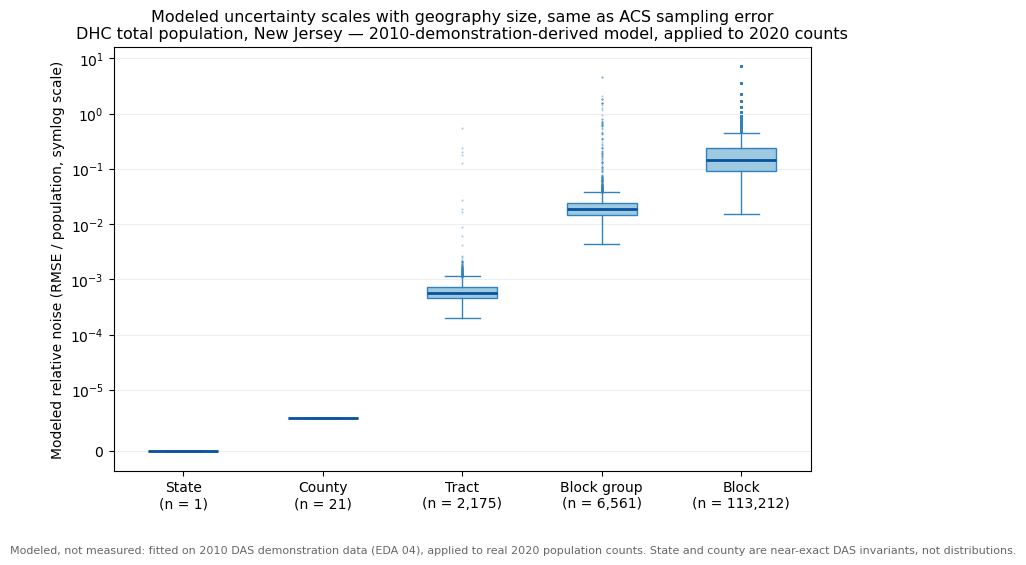

In [5]:
order = ["state", "county", "tract", "block_group", "block"]
pretty = {"state": "State", "county": "County", "tract": "Tract",
          "block_group": "Block group", "block": "Block"}
data = [modeled[lvl].dropna().to_numpy() for lvl in order]
tick_labels = [f"{pretty[lvl]}\n(n = {len(d):,})" for lvl, d in zip(order, data)]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(data, tick_labels=tick_labels, **viz.BOXPLOT_STYLE)
ax.set_yscale("symlog", linthresh=1e-5)
ax.set_axisbelow(True)
ax.grid(axis="y", which="both", alpha=0.2)

ax.set_ylabel("Modeled relative noise (RMSE / population, symlog scale)")
ax.set_title(
    "Modeled uncertainty scales with geography size, same as ACS sampling error\n"
    "DHC total population, New Jersey — 2010-demonstration-derived model, applied to 2020 counts",
    fontsize=11.5,
)
fig.text(
    0.01, -0.04,
    "Modeled, not measured: fitted on 2010 DAS demonstration data (EDA 04), applied to real "
    "2020 population counts. State and county are near-exact DAS invariants, not distributions.",
    fontsize=8, color="#666666",
)

viz.save_chart(fig, REPO_ROOT, "eda08_modeled_noise_by_geography.png")
plt.show()

In [6]:
# Guard the central claim: modeled noise must increase monotonically as geography shrinks.
med = {lvl: float(modeled[lvl].median()) for lvl in order}
assert med["state"] <= med["county"] <= med["tract"] <= med["block_group"] <= med["block"], med
print("Median modeled relative noise by level:", {k: round(v, 5) for k, v in med.items()})

Median modeled relative noise by level: {'state': 0.0, 'county': 1e-05, 'tract': 0.00057, 'block_group': 0.01843, 'block': 0.14173}


## 5. Findings

**What did we find?** The mechanism from ACS (EDA 01) reappears with a completely different noise source: reliability degrades sharply as geography shrinks, whether the noise comes from **sampling error** (ACS) or **injected privacy noise** (DHC/DP1). Modeled relative noise on total population climbs from essentially zero at state/county to a median of ~0.14 at block — comparable in *shape*, though not in mechanism, to ACS's county→block-group CV climb. We also confirmed something concrete rather than assumed: **DP1's total population is the exact same protected count as DHC's** (verified for all 2,181 tracts and 21 counties), so this one model serves both products for this variable.

**Why does it matter to the Census Bureau?** A county planner reading a DHC block-level count faces a reliability picture that *rhymes* with the ACS story planners may already be learning to expect — but the underlying honesty caveat is stronger here: this isn't a measurement of 2020 production noise -- it's a 2010-demonstration estimate, and those are not guaranteed to be the same thing. The demonstration release used to fit this model ran at *near*-production DAS settings as of 2022-08-25 (see `docs/data-dictionary.md`); the Census Bureau has not confirmed those settings are identical to what actually shipped in the 2020 production DHC/DP1 release. Concretely, "say so explicitly, not ACS-grade confidence" means: a dashboard should visually distinguish this number from an ACS CV -- e.g. label it "modeled, 2010-demonstration-derived" rather than "reliability score," avoid displaying it to false precision (two decimal places implies a measurement, not an extrapolated slope), and avoid the same hard-cutoff tier styling ACS's CV thresholds use, since those cutoffs were never validated against this noise source. ACS's CV is a direct, per-cell, current-vintage measurement; this number is an indirect, level-aggregated, decade-old-vintage estimate -- different epistemic status, and the dashboard should not let them look equally certain.

**What next?**
- **EDA 09 — variable type:** does a small subgroup (Black 65+) carry more modeled noise than total population, the way ACS's small subgroups did?
- **EDA 10 — geographic concentration:** map the modeled noise; because the model's only input is size, expect this map to closely mirror the (inverse of the) population map itself — a limitation worth demonstrating explicitly.
- **Open question for mentors:** is a real 2020-production noise measurement available or forthcoming, to replace this 2010-demonstration estimate?